# MAT 125 Precalculus Mathematics — LMC Data Analysis
**Northern Arizona University · Lumberjack Mathematics Center**

This notebook investigates student success in MAT 125 — Precalculus Mathematics — across Fall 2024 and Spring 2025.
We draw on three institutional data systems:

| Dataset | Grain | Key Questions |
|---------|-------|---------------|
| **SIS** | 1 row per student × section × term | Who are our students? What predicts success? |
| **Pearson** | 1 row per assignment × student | How do engagement and homework quality relate to outcomes? |
| **Canvas** | 1 row per student × section | Which topics trip students up? How does attendance track outcomes? |

> **Pass definition**: Grades A/B/C = Pass; D/F/W = Not Pass; blank grades excluded.  
> **Overall pass rate** (after deduplication): ~50.5%

In [39]:
#| label: setup
#| include: false

import warnings
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

OVERALL_PASS_RATE = master["Passed_int"].mean() * 100

master = pd.read_csv("Cleaned_For_DataSci/master_student.csv")
canvas = pd.read_csv("Cleaned_For_DataSci/canvas.csv", low_memory=False)
sis = pd.read_csv("Cleaned_For_DataSci\pearson.csv")
pearson = pd.read_csv("Cleaned_For_DataSci\pearson.csv")


def pass_rate_by(df, col, min_students=10):
    result = (
        df.groupby(col)["Passed_int"]
          .agg(pass_rate="mean", n="count")
          .reset_index()
    )
    result["pass_rate"] = result["pass_rate"] * 100
    result = result[result["n"] >= min_students]
    return result.sort_values("pass_rate")

## Part 1: Dataset Overview

Before diving into analysis, we confirm how many students appear across all three data systems.
A student may appear in SIS but not Pearson/Canvas if their data was not linked.
Understanding coverage prevents misleading conclusions from partial samples.

In [40]:
#| label: data-summary
#| fig-cap: "Student coverage across the three data systems."

sis_raw = pd.read_csv("Cleaned_For_DataSci/SIS.csv")
n_total   = len(master)
n_pearson = master["hw_completion_rate"].notna().sum()
n_canvas  = master["Check.Your.Understanding.Final.Score"].notna().sum()
n_all3    = (master["hw_completion_rate"].notna() &
             master["Check.Your.Understanding.Final.Score"].notna()).sum()

summary = pd.DataFrame({
    "Dataset":       ["SIS (raw)", "SIS graded", "SIS + Pearson", "SIS + Canvas", "All three systems"],
    "Students":      [len(sis_raw), n_total, n_pearson, n_canvas, n_all3],
    "Coverage (%)":  [100, n_total/len(sis_raw)*100,
                      n_pearson/n_total*100, n_canvas/n_total*100,
                      n_all3/n_total*100]
})
summary["Coverage (%)"] = summary["Coverage (%)"].round(1)
print(summary.to_string(index=False))

          Dataset  Students  Coverage (%)
        SIS (raw)      2320         100.0
       SIS graded      1783          76.9
    SIS + Pearson      1283          72.0
     SIS + Canvas      1134          63.6
All three systems      1124          63.0


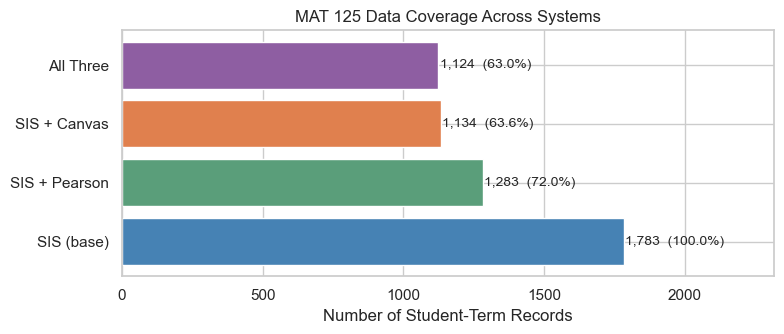

In [41]:
#| label: fig-coverage
#| fig-cap: "Student coverage across data systems."

labels = ["SIS (base)", "SIS + Pearson", "SIS + Canvas", "All Three"]
counts = [n_total, n_pearson, n_canvas, n_all3]
colors = ["steelblue", "#5a9e7a", "#e0804e", "#8e5ea2"]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(labels, counts, color=colors)
for bar, count in zip(bars, counts):
    pct = count / n_total * 100
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{count:,}  ({pct:.1f}%)", va="center", fontsize=10)
ax.set_xlabel("Number of Student-Term Records")
ax.set_title("MAT 125 Data Coverage Across Systems")
ax.set_xlim(0, n_total * 1.3)
plt.tight_layout()
plt.show()

## Part 2: SIS — Who Are Our Students & What Predicts Success?

The Student Information System (SIS) records enrollment, demographics, and academic history.
This section answers: *Where do students start? What demographics correlate with passing?*

> **Literature context**: Research consistently shows that academic preparation, first-generation status,
> and ethnicity interact with course outcomes in gateway math courses (Crisp et al., 2009;
> Bahr, 2010). We examine each factor independently before cross-referencing with engagement data.

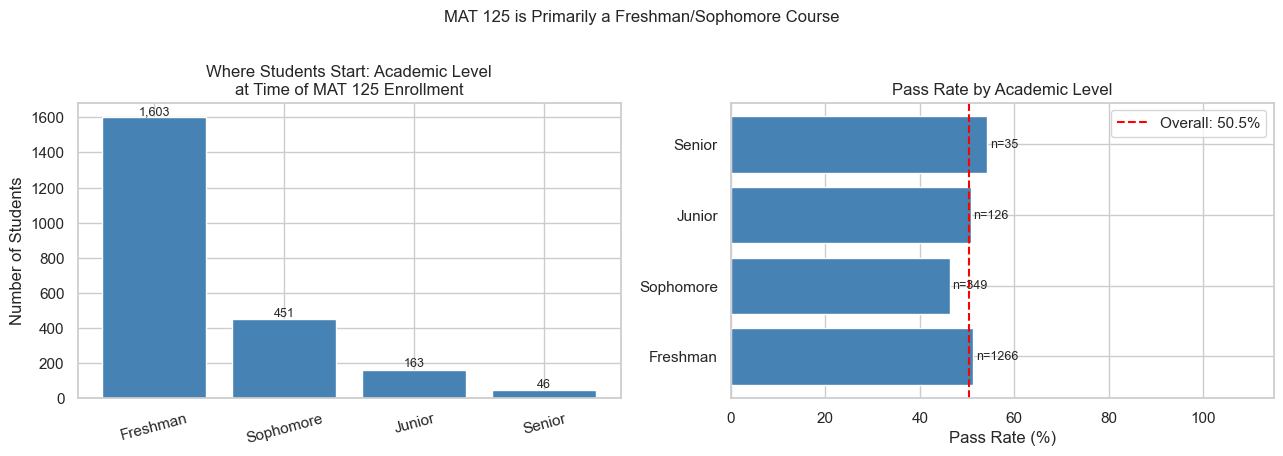

Freshmen make up 70.8% of MAT 125 students.

Pass rate by instruction mode:
Instruction.Mode  pass_rate    n
       In Person  50.085861 1747
          Online  69.444444   36


In [42]:
#| label: fig-academic-level
#| fig-cap: "Academic level at start of term and pass rate by academic level."

# Q: "Where are students starting?"
sis_raw = pd.read_csv("Cleaned_For_DataSci/SIS.csv")
LEVEL_ORDER = ["Freshman", "Sophomore", "Junior", "Senior"]

level_counts = (sis_raw["Academic.Level.Begin.of.Term"]
                .value_counts()
                .reindex(LEVEL_ORDER)
                .dropna())

level_pr = pass_rate_by(
    master[master["Academic.Level.Begin.of.Term"].isin(LEVEL_ORDER)],
    "Academic.Level.Begin.of.Term", min_students=10
).set_index("Academic.Level.Begin.of.Term").reindex(LEVEL_ORDER).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(level_counts.index, level_counts.values, color="steelblue", edgecolor="white")
for i, v in enumerate(level_counts.values):
    axes[0].text(i, v + 15, f"{v:,}", ha="center", fontsize=9)
axes[0].set_ylabel("Number of Students")
axes[0].set_title("Where Students Start: Academic Level\nat Time of MAT 125 Enrollment")
axes[0].tick_params(axis="x", rotation=15)

bars = axes[1].barh(level_pr.index, level_pr["pass_rate"], color="steelblue")
axes[1].axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
                label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (lvl, row) in zip(bars, level_pr.iterrows()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"n={int(row['n'])}", va="center", fontsize=9)
axes[1].set_xlabel("Pass Rate (%)")
axes[1].set_title("Pass Rate by Academic Level")
axes[1].set_xlim(0, 115)
axes[1].legend()

plt.suptitle("MAT 125 is Primarily a Freshman/Sophomore Course", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures/academic_level.png", dpi=150, bbox_inches="tight")
plt.show()

pct_fresh = level_counts["Freshman"] / level_counts.sum() * 100
print(f"Freshmen make up {pct_fresh:.1f}% of MAT 125 students.")
instr = master.groupby("Instruction.Mode")["Passed_int"].agg(
    pass_rate="mean", n="count").reset_index()
instr["pass_rate"] = instr["pass_rate"] * 100
print("\nPass rate by instruction mode:")
print(instr.to_string(index=False))

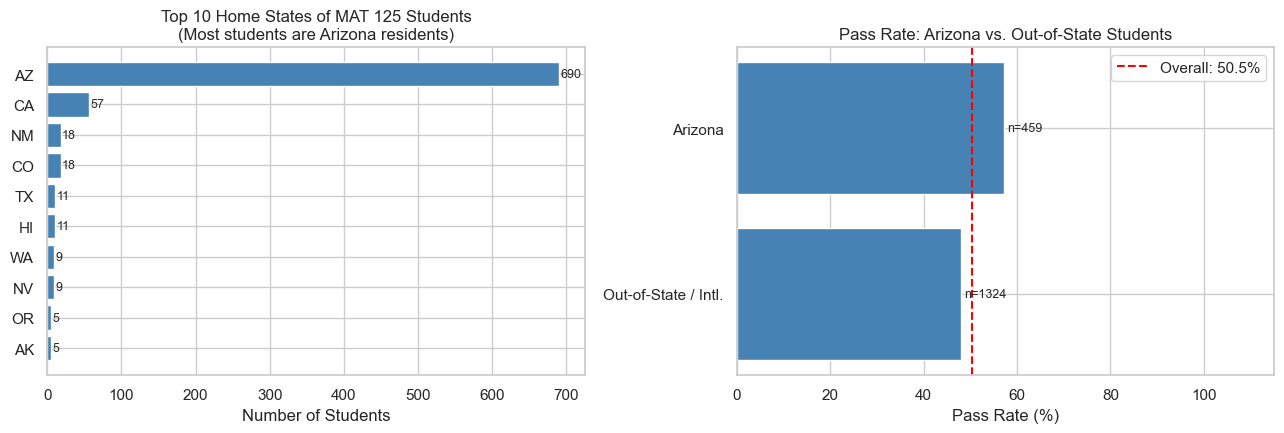

In [43]:
#| label: fig-geography
#| fig-cap: "Where MAT 125 students come from (home state)."

# Q: "Where do students start on campus?" — geographic perspective
state_counts = (sis_raw["Home.State.Cd"]
                .value_counts()
                .head(10)
                .sort_values())

master_geo = master.copy()
master_geo["origin"] = master_geo["Home.State.Cd"].apply(
    lambda x: "Arizona" if str(x).strip() == "AZ" else "Out-of-State / Intl.")
geo_pr = pass_rate_by(master_geo.dropna(subset=["origin"]), "origin", min_students=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(state_counts.index, state_counts.values, color="steelblue")
for i, v in enumerate(state_counts.values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=9)
axes[0].set_xlabel("Number of Students")
axes[0].set_title("Top 10 Home States of MAT 125 Students\n(Most students are Arizona residents)")

bars = axes[1].barh(geo_pr["origin"], geo_pr["pass_rate"], color="steelblue")
axes[1].axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
                label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, geo_pr.iterrows()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"n={int(row['n'])}", va="center", fontsize=9)
axes[1].set_xlabel("Pass Rate (%)")
axes[1].set_title("Pass Rate: Arizona vs. Out-of-State Students")
axes[1].set_xlim(0, 115)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/geography.png", dpi=150, bbox_inches="tight")
plt.show()

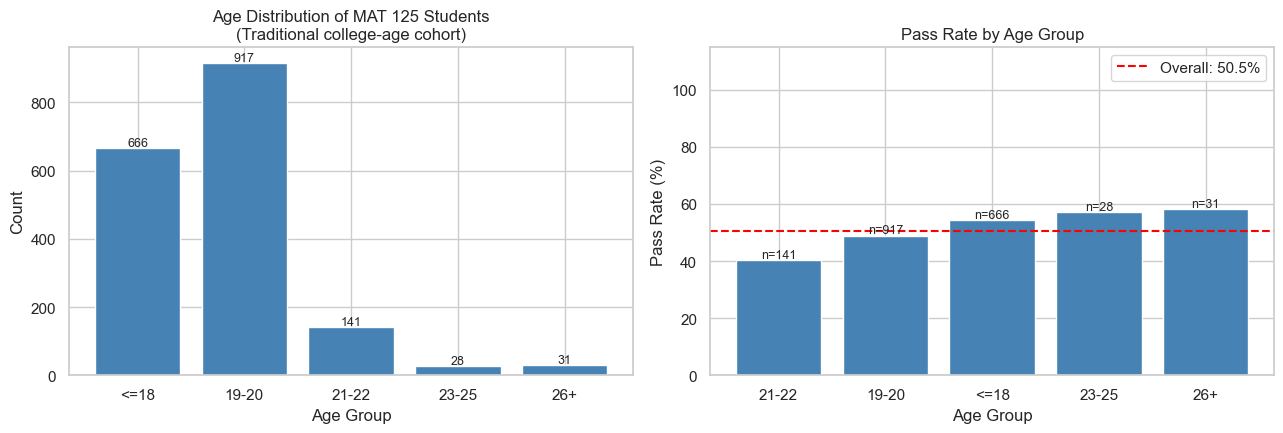

Median student age: 19 years


In [44]:
#| label: fig-age
#| fig-cap: "Age distribution and pass rate by age group."

# Q: "What demographics lead to student success?" — Age factor
age_bins = [0, 18, 20, 22, 25, 100]
age_labs = ["<=18", "19-20", "21-22", "23-25", "26+"]
master_age = master.copy()
master_age["age_group"] = pd.cut(master_age["Age"], bins=age_bins,
                                  labels=age_labs, right=True)

age_dist = master_age["age_group"].value_counts().sort_index()
age_pr   = pass_rate_by(master_age.dropna(subset=["age_group"]),
                         "age_group", min_students=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(age_dist.index.astype(str), age_dist.values,
            color="steelblue", edgecolor="white")
for i, v in enumerate(age_dist.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution of MAT 125 Students\n(Traditional college-age cohort)")

bars = axes[1].bar(age_pr["age_group"].astype(str),
                   age_pr["pass_rate"], color="steelblue", edgecolor="white")
axes[1].axhline(OVERALL_PASS_RATE, color="red", linestyle="--",
                label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, age_pr.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f"n={int(row['n'])}", ha="center", fontsize=9)
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Pass Rate (%)")
axes[1].set_title("Pass Rate by Age Group")
axes[1].set_ylim(0, 115)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/age_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median student age: {master_age['Age'].median():.0f} years")

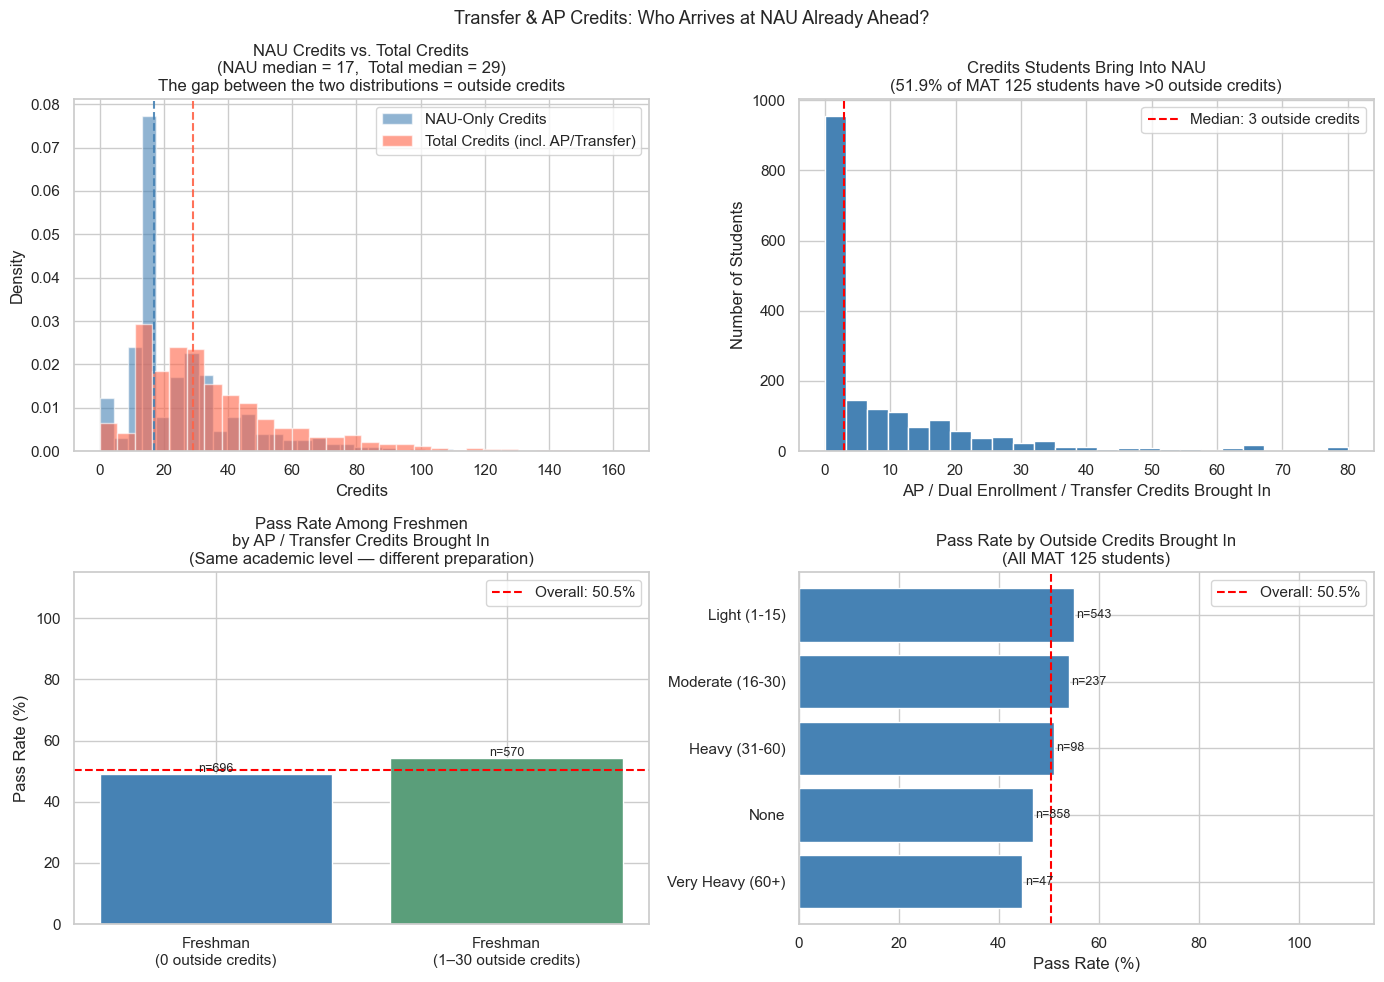

51.9% of MAT 125 students have non-NAU credits
Among those with outside credits, median = 12 credits
Freshmen with 30+ outside credits (academic sophomores): 0


In [45]:
#| label: fig-nau-credits
#| fig-cap: "Transfer credit analysis: NAU credits vs. total credits at enrollment."

# Q: "How many credits are taken at NAU?"
# Two columns tell very different stories:
#   Total.NAU.Units  = credits earned AT Northern Arizona University only
#   Total.Cum.Units  = ALL credits (NAU + AP exams + dual enrollment + transfer)
# The gap (Total.Cum.Units - Total.NAU.Units) = "outside credits" a student brings in.
# This reveals students who arrive already ahead — academic sophomores enrolled as freshmen.

master_cr = master.copy()
master_cr["transfer_credits"] = (
    master_cr["Total.Cum.Units"] - master_cr["Total.NAU.Units"]
).clip(lower=0)

tc_bins = [-1, 0, 15, 30, 60, 300]
tc_labs = ["None", "Light (1-15)", "Moderate (16-30)", "Heavy (31-60)", "Very Heavy (60+)"]
master_cr["tc_group"] = pd.cut(master_cr["transfer_credits"], bins=tc_bins, labels=tc_labs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Top-left: Overlaid histograms — NAU credits vs. Total credits ──────────────
axes[0, 0].hist(master_cr["Total.NAU.Units"].dropna(), bins=30, alpha=0.6,
                color="steelblue", label="NAU-Only Credits", density=True)
axes[0, 0].hist(master_cr["Total.Cum.Units"].dropna(), bins=30, alpha=0.6,
                color="tomato", label="Total Credits (incl. AP/Transfer)", density=True)
nau_med = master_cr["Total.NAU.Units"].median()
cum_med = master_cr["Total.Cum.Units"].median()
axes[0, 0].axvline(nau_med, color="steelblue", linestyle="--", alpha=0.9)
axes[0, 0].axvline(cum_med, color="tomato",    linestyle="--", alpha=0.9)
axes[0, 0].set_xlabel("Credits")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title(f"NAU Credits vs. Total Credits\n"
                     f"(NAU median = {nau_med:.0f},  Total median = {cum_med:.0f})\n"
                     f"The gap between the two distributions = outside credits")
axes[0, 0].legend()

# ── Top-right: Distribution of outside credits ─────────────────────────────────
tc_vals = master_cr["transfer_credits"].dropna().clip(0, 80)
axes[0, 1].hist(tc_vals, bins=25, color="steelblue", edgecolor="white")
tc_med = master_cr["transfer_credits"].median()
axes[0, 1].axvline(tc_med, color="red", linestyle="--",
                   label=f"Median: {tc_med:.0f} outside credits")
pct_nonzero = (master_cr["transfer_credits"] > 0).mean() * 100
axes[0, 1].set_xlabel("AP / Dual Enrollment / Transfer Credits Brought In")
axes[0, 1].set_ylabel("Number of Students")
axes[0, 1].set_title(f"Credits Students Bring Into NAU\n"
                     f"({pct_nonzero:.1f}% of MAT 125 students have >0 outside credits)")
axes[0, 1].legend()

# ── Bottom-left: Pass rate among freshmen split by outside credit level ─────────
is_fresh = master_cr["Academic.Level.Begin.of.Term"] == "Freshman"
fresh_groups = {
    "Freshman\n(0 outside credits)":      is_fresh & (master_cr["transfer_credits"] == 0),
    "Freshman\n(1–30 outside credits)":   is_fresh & master_cr["transfer_credits"].between(1, 30),
    "Freshman\n(30+ outside credits)":    is_fresh & (master_cr["transfer_credits"] > 30),
}
fr_labels, fr_rates, fr_ns = [], [], []
for label, mask in fresh_groups.items():
    subset = master_cr[mask]
    if len(subset) >= 5:
        fr_labels.append(label)
        fr_rates.append(subset["Passed_int"].mean() * 100)
        fr_ns.append(len(subset))

bar_colors = ["steelblue", "#5a9e7a", "tomato"]
bars = axes[1, 0].bar(fr_labels, fr_rates,
                      color=bar_colors[:len(fr_labels)], edgecolor="white")
axes[1, 0].axhline(OVERALL_PASS_RATE, color="red", linestyle="--",
                   label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, n in zip(bars, fr_ns):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8, f"n={n}", ha="center", fontsize=9)
axes[1, 0].set_ylabel("Pass Rate (%)")
axes[1, 0].set_ylim(0, 115)
axes[1, 0].set_title("Pass Rate Among Freshmen\nby AP / Transfer Credits Brought In\n"
                     "(Same academic level — different preparation)")
axes[1, 0].legend()

# ── Bottom-right: Pass rate by outside credit group (all students) ─────────────
tc_pr = pass_rate_by(master_cr.dropna(subset=["tc_group"]), "tc_group", min_students=10)
bars2 = axes[1, 1].barh(tc_pr["tc_group"].astype(str),
                         tc_pr["pass_rate"], color="steelblue")
axes[1, 1].axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
                   label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars2, tc_pr.iterrows()):
    axes[1, 1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"n={int(row['n'])}", va="center", fontsize=9)
axes[1, 1].set_xlabel("Pass Rate (%)")
axes[1, 1].set_title("Pass Rate by Outside Credits Brought In\n(All MAT 125 students)")
axes[1, 1].set_xlim(0, 115)
axes[1, 1].legend()

plt.suptitle("Transfer & AP Credits: Who Arrives at NAU Already Ahead?", fontsize=13)
plt.tight_layout()
plt.savefig("figures/nau_credits.png", dpi=150, bbox_inches="tight")
plt.show()

med_outside = master_cr[master_cr["transfer_credits"] > 0]["transfer_credits"].median()
n_fresh_ahead = (is_fresh & (master_cr["transfer_credits"] > 30)).sum()
print(f"{pct_nonzero:.1f}% of MAT 125 students have non-NAU credits")
print(f"Among those with outside credits, median = {med_outside:.0f} credits")
print(f"Freshmen with 30+ outside credits (academic sophomores): {n_fresh_ahead}")

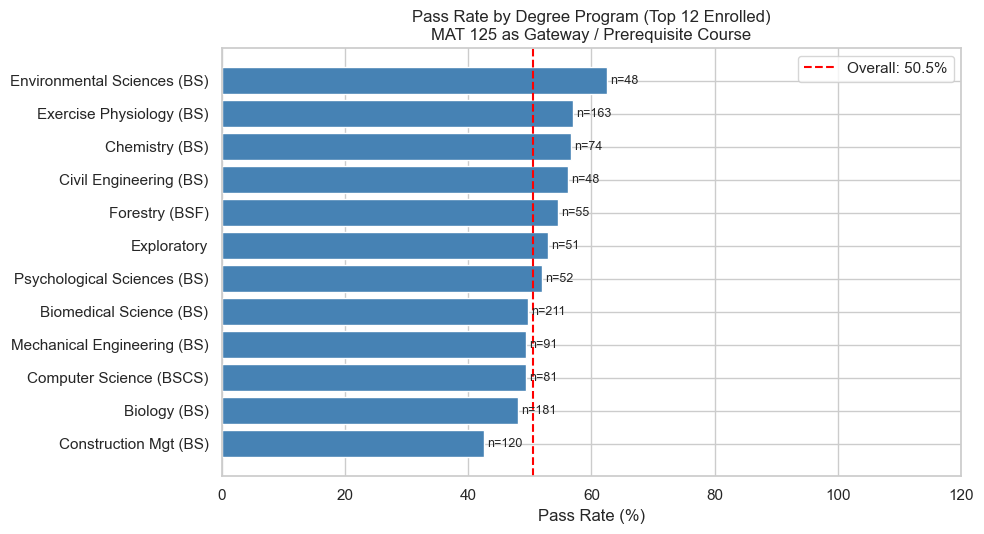

Enrollment by top program:
Primary.Academic.Plan
Biomedical Science (BS)          211
Biology (BS)                     181
Exercise Physiology (BS)         163
Construction Mgt (BS)            120
Mechanical Engineering (BS)       91
Computer Science (BSCS)           81
Chemistry (BS)                    74
Forestry (BSF)                    55
Psychological Sciences (BS)       52
Exploratory                       51
Civil Engineering (BS)            48
Environmental Sciences (BS)       48
Ecol & Evol Biology (BS)          35
ImmersiveMedia&Games (BS)         33
Electrical Engineering (BS)       31
Geology (BS)                      28
Software Engineering (BS)         28
Computer Engineering (BS)         27
Nursing (BSN)                     27
Environmental Engr (BS)           25
Engineering-Undecided             18
HlthSci-Fit Wellness (BS)         17
Microbiology (BS)                 16
Astronomy (BS)                    16
Physics & Astrophysics (BS)       15
MultDiscp Engineering (BS)

In [46]:
#| label: fig-major
#| fig-cap: "Pass rate for the top 12 enrolled degree programs in MAT 125."

# Q: "Based on degree, what is the terminal math course? What percentage pass?"
# MAT 125 is a gateway/prerequisite; we show which programs send the most students
# and how each program fares — useful for advising interventions.
top_plans = (master["Primary.Academic.Plan"]
             .value_counts().head(TOP_N).index.tolist())

major_df = pass_rate_by(
    master[master["Primary.Academic.Plan"].isin(top_plans)],
    "Primary.Academic.Plan", min_students=10
)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(major_df["Primary.Academic.Plan"],
               major_df["pass_rate"], color="steelblue")
ax.axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
           label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, major_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("Pass Rate by Degree Program (Top 12 Enrolled)\n"
             "MAT 125 as Gateway / Prerequisite Course")
ax.set_xlim(0, 120)
ax.legend()
plt.tight_layout()
plt.savefig("figures/major_pass_rate.png", dpi=150, bbox_inches="tight")
plt.show()

print("Enrollment by top program:")
print(master["Primary.Academic.Plan"].value_counts().to_string())

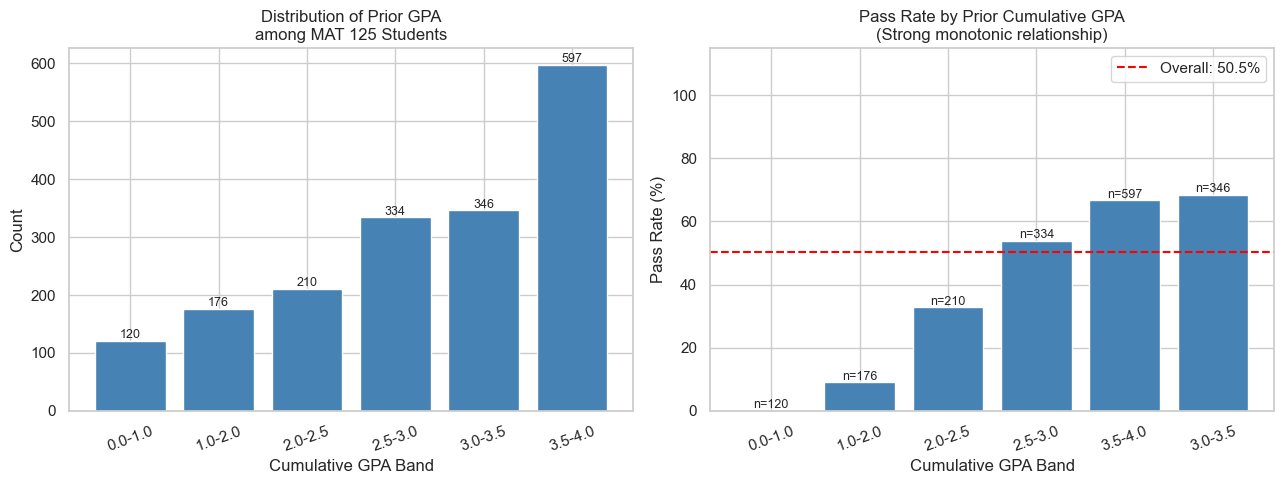

Pearson r (Cum.GPA vs Passed_int): 0.436
Median GPA — passing students:     3.43
Median GPA — non-passing students: 2.55


In [47]:
#| label: fig-gpa
#| fig-cap: "Prior cumulative GPA as a predictor of MAT 125 success."

# Q: "What demographics lead to student success?" — Prior GPA
# Cum.GPA reflects academic preparation entering the course.
gpa_bins = [-0.1, 1.0, 2.0, 2.5, 3.0, 3.5, 4.01]
gpa_labs = ["0.0-1.0", "1.0-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0"]

master_gpa = master.copy()
master_gpa["gpa_band"] = pd.cut(master_gpa["Cum.GPA"],
                                 bins=gpa_bins, labels=gpa_labs)
gpa_pr = pass_rate_by(master_gpa.dropna(subset=["gpa_band"]),
                       "gpa_band", min_students=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gpa_dist = master_gpa["gpa_band"].value_counts().sort_index()
axes[0].bar(gpa_dist.index.astype(str), gpa_dist.values,
            color="steelblue", edgecolor="white")
for i, v in enumerate(gpa_dist.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)
axes[0].set_xlabel("Cumulative GPA Band")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Prior GPA\namong MAT 125 Students")
axes[0].tick_params(axis="x", rotation=20)

bars = axes[1].bar(gpa_pr["gpa_band"].astype(str),
                   gpa_pr["pass_rate"], color="steelblue", edgecolor="white")
axes[1].axhline(OVERALL_PASS_RATE, color="red", linestyle="--",
                label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, gpa_pr.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f"n={int(row['n'])}", ha="center", fontsize=9)
axes[1].set_xlabel("Cumulative GPA Band")
axes[1].set_ylabel("Pass Rate (%)")
axes[1].set_title("Pass Rate by Prior Cumulative GPA\n(Strong monotonic relationship)")
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/gpa_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

corr = master_gpa[["Cum.GPA", "Passed_int"]].dropna().corr().iloc[0, 1]
print(f"Pearson r (Cum.GPA vs Passed_int): {corr:.3f}")
print(f"Median GPA — passing students:     "
      f"{master_gpa[master_gpa['Passed']     ]['Cum.GPA'].median():.2f}")
print(f"Median GPA — non-passing students: "
      f"{master_gpa[~master_gpa['Passed']    ]['Cum.GPA'].median():.2f}")

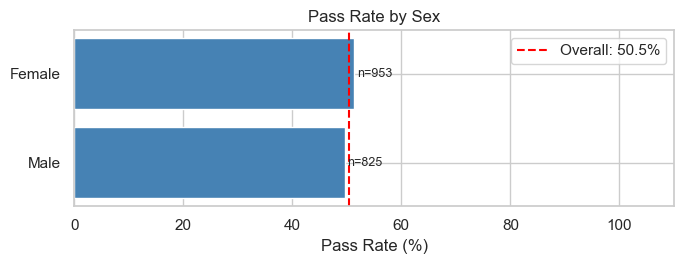

In [48]:
#| label: fig-sex
#| fig-cap: "Pass rate by student sex."

sex_df = pass_rate_by(master, "Sex")
fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(sex_df["Sex"], sex_df["pass_rate"], color="steelblue")
ax.axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
           label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, sex_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("Pass Rate by Sex")
ax.set_xlim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

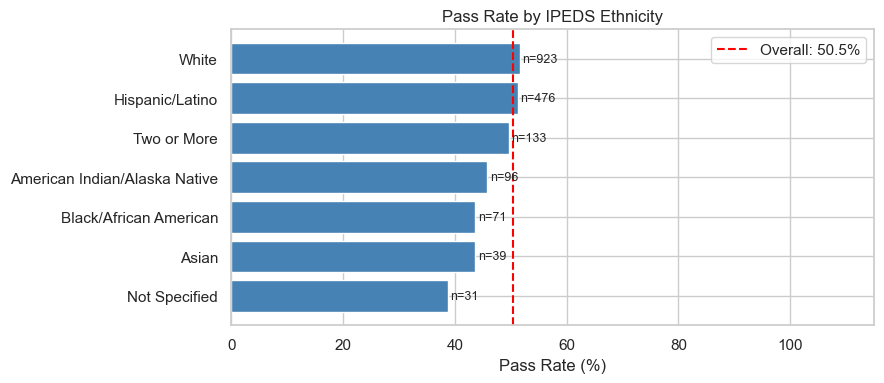

In [49]:
#| label: fig-ethnicity
#| fig-cap: "Pass rate by IPEDS Ethnicity (groups with n < 15 excluded)."

eth_df = pass_rate_by(master, "IPEDS.Ethnicity", min_students=15)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(eth_df["IPEDS.Ethnicity"], eth_df["pass_rate"], color="steelblue")
ax.axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
           label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, eth_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("Pass Rate by IPEDS Ethnicity")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

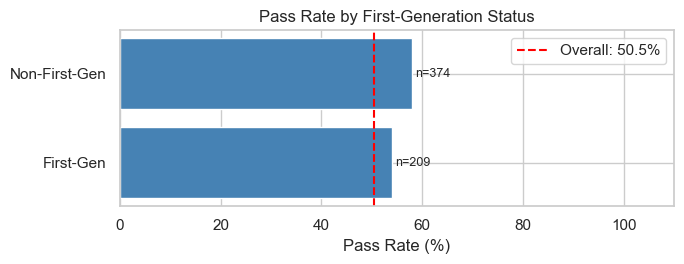

In [50]:
#| label: fig-firstgen
#| fig-cap: "Pass rate by first-generation college student status."

gen = master.copy()
gen["FirstGen.Label"] = gen["X1st.Gen.College.Std.Flag"].map(
    {"Y": "First-Gen", "N": "Non-First-Gen"}
)
gen_df = pass_rate_by(gen.dropna(subset=["FirstGen.Label"]), "FirstGen.Label")

fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(gen_df["FirstGen.Label"], gen_df["pass_rate"], color="steelblue")
ax.axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
           label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, gen_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("Pass Rate by First-Generation Status")
ax.set_xlim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

## Part 3: Pearson — Assignment Engagement & Quality

Pearson MyLab is the online homework platform for MAT 125.
Each row in `pearson.csv` represents one assignment attempt.
We explore three questions:

1. **Do Unit 1 exam scores predict final outcomes?** (Early warning signal)
2. **Can we find quality trends across assignment types?** (Homework vs. Tests vs. Quizzes)
3. **Can we detect disengaged or AI-assisted work?** (Fast-submit patterns)

> **Why it matters**: Research on gateway math courses shows that early assessment performance
> is one of the strongest predictors of course success (Crisp et al., 2009).
> Similarly, time-on-task is a validated proxy for meaningful learning effort (Karweit & Slavin, 1982).

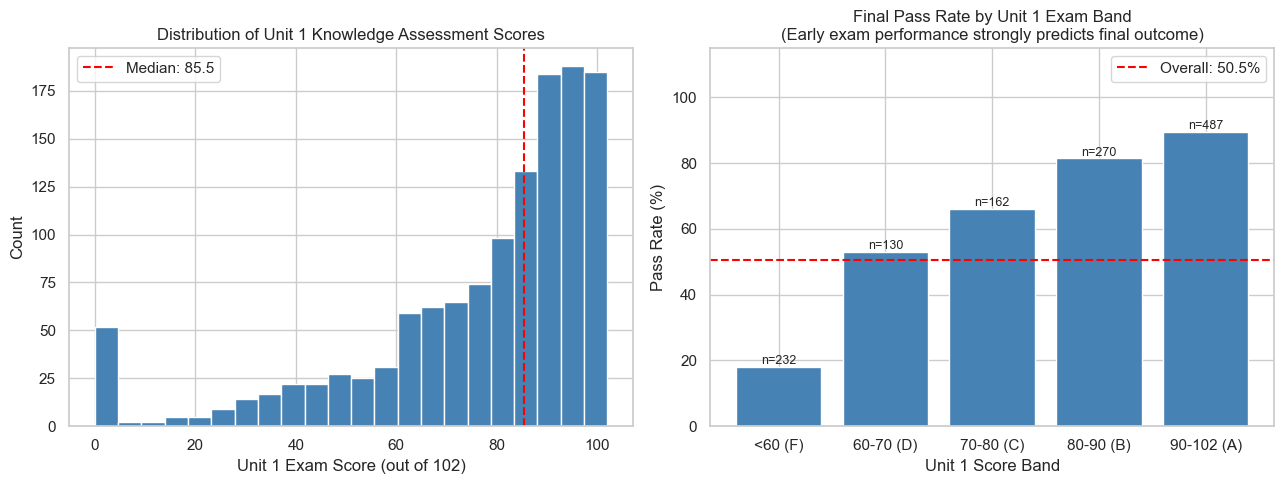

Pearson r (Unit 1 score vs pass): 0.562
Pass rate for U1 <60:  18.1%
Pass rate for U1 >=90: 89.5%


In [51]:
#| label: fig-unit1-exam
#| fig-cap: "Unit 1 exam score as an early predictor of final pass/fail."

# Q: "Do Unit 1 exams affect final grades?"
# unit1_exam_score = Unit 1 Knowledge Assessment from Canvas, merged into master.
has_u1 = master.dropna(subset=["unit1_exam_score"]).copy()

u1_bins = [-1, 60, 70, 80, 90, 103]
u1_labs = ["<60 (F)", "60-70 (D)", "70-80 (C)", "80-90 (B)", "90-102 (A)"]
has_u1["u1_band"] = pd.cut(has_u1["unit1_exam_score"],
                            bins=u1_bins, labels=u1_labs)
u1_pr = pass_rate_by(has_u1.dropna(subset=["u1_band"]),
                     "u1_band", min_students=5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(has_u1["unit1_exam_score"].dropna(), bins=22,
             color="steelblue", edgecolor="white")
med_u1 = has_u1["unit1_exam_score"].median()
axes[0].axvline(med_u1, color="red", linestyle="--",
                label=f"Median: {med_u1:.1f}")
axes[0].set_xlabel("Unit 1 Exam Score (out of 102)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Unit 1 Knowledge Assessment Scores")
axes[0].legend()

bars = axes[1].bar(u1_pr["u1_band"].astype(str),
                   u1_pr["pass_rate"], color="steelblue", edgecolor="white")
axes[1].axhline(OVERALL_PASS_RATE, color="red", linestyle="--",
                label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, u1_pr.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f"n={int(row['n'])}", ha="center", fontsize=9)
axes[1].set_xlabel("Unit 1 Score Band")
axes[1].set_ylabel("Pass Rate (%)")
axes[1].set_title("Final Pass Rate by Unit 1 Exam Band\n"
                  "(Early exam performance strongly predicts final outcome)")
axes[1].set_ylim(0, 115)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/unit1_exam.png", dpi=150, bbox_inches="tight")
plt.show()

corr_u1 = has_u1[["unit1_exam_score", "Passed_int"]].corr().iloc[0, 1]
low_u1_pass  = has_u1[has_u1["unit1_exam_score"] <  60]["Passed_int"].mean() * 100
high_u1_pass = has_u1[has_u1["unit1_exam_score"] >= 90]["Passed_int"].mean() * 100
print(f"Pearson r (Unit 1 score vs pass): {corr_u1:.3f}")
print(f"Pass rate for U1 <60:  {low_u1_pass:.1f}%")
print(f"Pass rate for U1 >=90: {high_u1_pass:.1f}%")

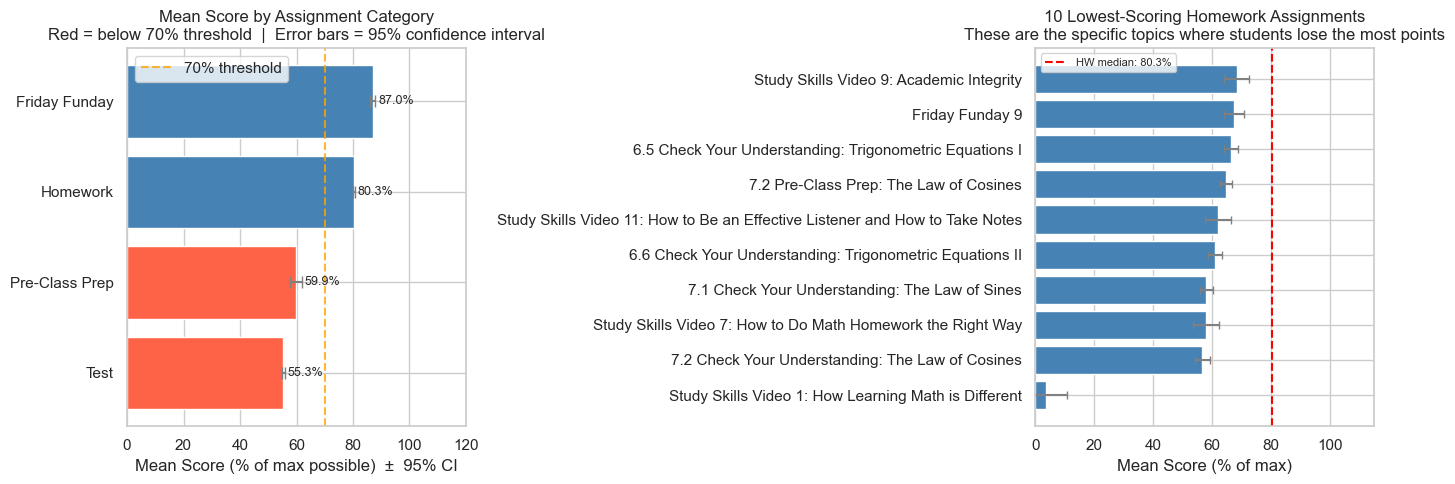

Mean score (%) by assignment category:
Assignment.Category      mean  count
               Test 55.302846  15585
     Pre-Class Prep 59.889604   2174
           Homework 80.334013  92785
      Friday Funday 86.971161   2558


In [52]:
#| label: fig-assignment-quality
#| fig-cap: "Mean score by assignment category and the 10 lowest-scoring homework assignments."

# Q: "Can we find trends about the quality of assignments?"
# We normalize each assignment to % of its own maximum possible score,
# so we can compare categories that have different point values.
pearson_raw = pd.read_csv("Cleaned_For_DataSci/pearson.csv")
pearson_raw["Score_num"] = pd.to_numeric(pearson_raw["Score"], errors="coerce")

focus_cats = ["Homework", "Test", "Quiz", "Pre-Class Prep", "Friday Funday"]
pcat = pearson_raw[pearson_raw["Assignment.Category"].isin(focus_cats)].copy()
pcat = pcat.dropna(subset=["Score_num"])

cat_max = (pcat.groupby(["Assignment.Category", "Assignment.Title"])["Score_num"]
           .max().reset_index(name="max_score"))
pcat = pcat.merge(cat_max, on=["Assignment.Category", "Assignment.Title"])
pcat = pcat[pcat["max_score"] > 0]
pcat["score_pct"] = (pcat["Score_num"] / pcat["max_score"] * 100).clip(0, 110)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Mean score per category with 95% CI ──────────────────────────────────
# (Bar chart is clearer than a box plot for showing where each category stands)
cat_stats = (pcat.groupby("Assignment.Category")["score_pct"]
             .agg(mean="mean", std="std", count="count")
             .reset_index()
             .sort_values("mean"))
cat_stats["ci95"] = 1.96 * cat_stats["std"] / cat_stats["count"].pow(0.5)

bar_colors = ["tomato" if m < 70 else "steelblue" for m in cat_stats["mean"]]
axes[0].barh(cat_stats["Assignment.Category"], cat_stats["mean"],
             xerr=cat_stats["ci95"], color=bar_colors,
             error_kw=dict(ecolor="gray", capsize=4))
axes[0].axvline(70, color="orange", linestyle="--", alpha=0.8, label="70% threshold")
for i, (_, row) in enumerate(cat_stats.iterrows()):
    axes[0].text(row["mean"] + row["ci95"] + 1, i,
                 f'{row["mean"]:.1f}%', va="center", fontsize=9)
axes[0].set_xlabel("Mean Score (% of max possible)  ±  95% CI")
axes[0].set_title("Mean Score by Assignment Category\n"
                  "Red = below 70% threshold  |  Error bars = 95% confidence interval")
axes[0].set_xlim(0, 120)
axes[0].legend()

# ── Right: 10 lowest-scoring homework assignments ─────────────────────────────
hw = pcat[pcat["Assignment.Category"] == "Homework"].copy()
hw_agg = (hw.groupby("Assignment.Title")["score_pct"]
          .agg(mean_score="mean",
               sem_score=lambda x: x.std() / (len(x) ** 0.5))
          .reset_index()
          .sort_values("mean_score"))
bot10_hw = hw_agg.head(10)
hw_median = hw_agg["mean_score"].median()

axes[1].barh(bot10_hw["Assignment.Title"], bot10_hw["mean_score"],
             xerr=bot10_hw["sem_score"] * 1.96, color="steelblue",
             error_kw=dict(ecolor="gray", capsize=3))
axes[1].axvline(hw_median, color="red", linestyle="--",
                label=f"HW median: {hw_median:.1f}%")
axes[1].set_xlabel("Mean Score (% of max)")
axes[1].set_title("10 Lowest-Scoring Homework Assignments\n"
                  "These are the specific topics where students lose the most points")
axes[1].set_xlim(0, 115)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/assignment_quality.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean score (%) by assignment category:")
print(cat_stats[["Assignment.Category", "mean", "count"]].to_string(index=False))

### Homework Score Quartile vs. Pass Rate

The chart below divides students into **four equal groups (quartiles)** based on their average Pearson homework score:

| Quartile | Meaning |
|----------|---------|
| **Q1 (Bottom 25%)** | Students with the lowest homework averages relative to their peers |
| **Q2 (25–50%)** | Below-median homework performers |
| **Q3 (50–75%)** | Above-median homework performers |
| **Q4 (Top 25%)** | Students with the highest homework averages relative to their peers |

> A **quartile** is a *relative* ranking — it compares students to each other, not to a fixed score threshold.  
> Q4 does not mean the student scored above 75%; it means they scored in the top 25% of all students.

**Why does this matter?**  
The gap between Q1 and Q4 pass rates is often 60+ percentage points.  
This makes homework performance one of the **strongest single predictors** of passing MAT 125 — stronger than most demographic factors.  
This is consistent with Hattie's (2009) finding that formative assessment is among the highest-impact interventions in education.

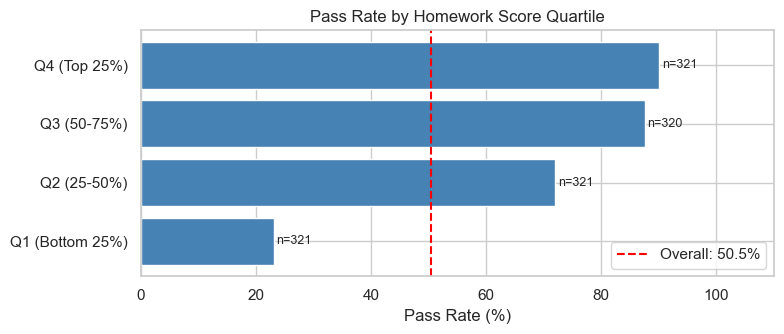

Top quartile: 90.0%  |  Bottom quartile: 23.1%  |  Gap: 67.0 pts


In [53]:
#| label: fig-hw-quartile
#| fig-cap: "Pass rate by homework score quartile. Top-quartile students show dramatically higher pass rates."

has_pearson = master.dropna(subset=["hw_score_mean"]).copy()
has_pearson["hw_score_quartile"] = pd.qcut(
    has_pearson["hw_score_mean"],
    q=4,
    labels=["Q1 (Bottom 25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (Top 25%)"],
    duplicates="drop"
)
hw_q_df = pass_rate_by(has_pearson.dropna(subset=["hw_score_quartile"]),
                        "hw_score_quartile", min_students=10)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(
    hw_q_df["hw_score_quartile"].astype(str),
    hw_q_df["pass_rate"],
    color="steelblue"
)
ax.axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
           label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, hw_q_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}", va="center", fontsize=9)
ax.set_xlabel("Pass Rate (%)")
ax.set_title("Pass Rate by Homework Score Quartile")
ax.set_xlim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

top_q = hw_q_df[hw_q_df["hw_score_quartile"].astype(str).str.contains("Top")]["pass_rate"].values
bot_q = hw_q_df[hw_q_df["hw_score_quartile"].astype(str).str.contains("Bottom")]["pass_rate"].values
if len(top_q) and len(bot_q):
    print(f"Top quartile: {top_q[0]:.1f}%  |  Bottom quartile: {bot_q[0]:.1f}%  |  Gap: {top_q[0]-bot_q[0]:.1f} pts")

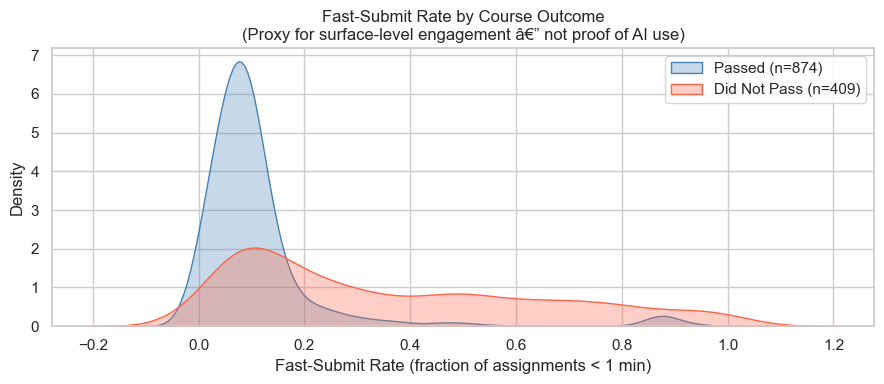

Overall mean fast-submit rate: 19.5% of assignments


In [54]:
#| label: fig-fast-submit
#| fig-cap: "Distribution of fast-submit rates (fraction of assignments completed in < 1 min) by course outcome."

fig, ax = plt.subplots(figsize=(9, 4))
for passed, label, color in [(True, "Passed", "steelblue"), (False, "Did Not Pass", "tomato")]:
    subset = has_pearson[has_pearson["Passed"] == passed]["hw_fast_submit_rate"].dropna()
    sns.kdeplot(subset, ax=ax, label=f"{label} (n={len(subset):,})",
                color=color, fill=True, alpha=0.3, bw_adjust=0.8)
ax.set_xlabel("Fast-Submit Rate (fraction of assignments < 1 min)")
ax.set_ylabel("Density")
ax.set_title("Fast-Submit Rate by Course Outcome\n(Proxy for surface-level engagement â€” not proof of AI use)")
ax.legend()
plt.tight_layout()
plt.show()

overall_pct = has_pearson["hw_fast_submit_rate"].mean() * 100
print(f"Overall mean fast-submit rate: {overall_pct:.1f}% of assignments")

## Part 4: Canvas — Topics, Attendance & Semester Patterns

Canvas records weekly attendance, Check Your Understanding (CYU) pre-class prep scores,
Friday Funday participation, and assignment grades.

Questions addressed:
- **Which topics are most confusing?** (CYU item analysis)
- **Is attendance consistent across semesters?** (Fall 2024 vs. Spring 2025)
- **Can we track student progression?** (Weekly attendance trajectory by outcome)
- **Can we identify critical inflection points?** (Attendance divergence timing)

> **Note**: Canvas uses section-specific column names.
> We extract topic labels via regex and aggregate across sections.

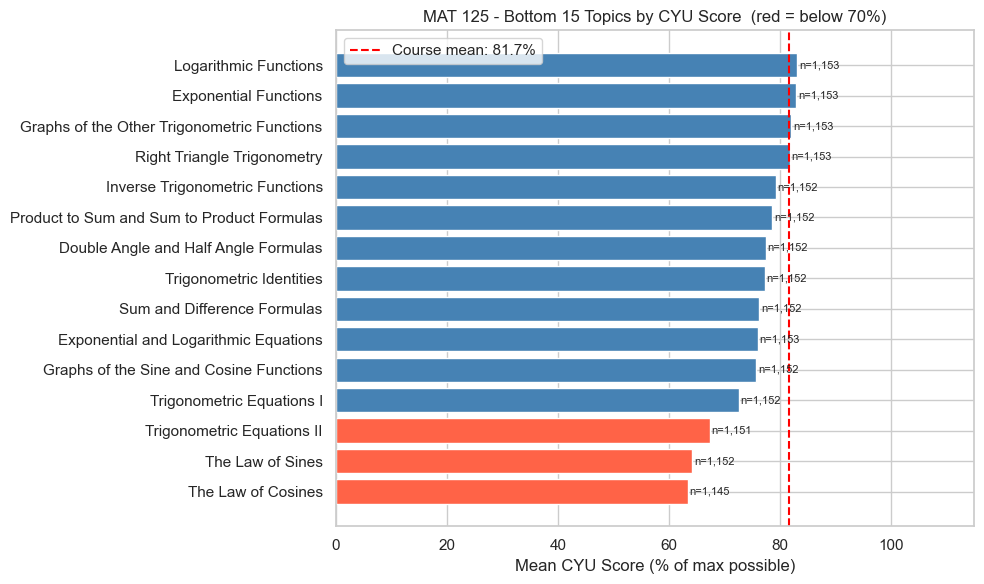

Hardest topic: The Law of Cosines  at 63.4%  (18.3 pts below course mean)


In [55]:
#| label: fig-cyu-topics
#| fig-cap: "Bottom 15 topics by mean CYU score. Red bars are below 70%."

def extract_cyu_topic(col):
    m = re.search(r"Check\.Your\.Understanding\.\.(.+?)\.\.\d+", col)
    if m:
        raw = m.group(1)
        cleaned = raw.replace("...", " / ").replace("..", " / ").replace(".", " ")
        return cleaned.strip()
    return None

cyu_item_cols = [
    c for c in canvas.columns
    if "Check.Your.Understanding" in c
    and "Final.Score" not in c
    and "Unposted" not in c
    and "Current.Score" not in c
]

topic_buckets = {}
for col in cyu_item_cols:
    topic = extract_cyu_topic(col)
    if topic is None:
        continue
    vals = pd.to_numeric(canvas[col], errors="coerce").dropna()
    if len(vals) == 0:
        continue
    col_max = vals.max()
    if col_max > 0:
        pct_scores = (vals / col_max * 100).tolist()
        topic_buckets.setdefault(topic, []).extend(pct_scores)

topic_df = pd.DataFrame([
    {"topic": t, "mean_pct": np.mean(v), "n": len(v)}
    for t, v in topic_buckets.items()
    if len(v) >= 50
]).sort_values("mean_pct")

overall_cyu_mean = topic_df["mean_pct"].mean()
bottom15 = topic_df.head(15).copy()
bar_colors = ["tomato" if v < 70 else "steelblue" for v in bottom15["mean_pct"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(bottom15["topic"], bottom15["mean_pct"], color=bar_colors)
ax.axvline(overall_cyu_mean, color="red", linestyle="--",
           label=f"Course mean: {overall_cyu_mean:.1f}%")
for bar, (_, row) in zip(bars, bottom15.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n']):,}", va="center", fontsize=8)
ax.set_xlabel("Mean CYU Score (% of max possible)")
ax.set_title("MAT 125 - Bottom 15 Topics by CYU Score  (red = below 70%)")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

hardest = topic_df.iloc[0]
print(f"Hardest topic: {hardest['topic']}  at {hardest['mean_pct']:.1f}%  "
      f"({overall_cyu_mean - hardest['mean_pct']:.1f} pts below course mean)")

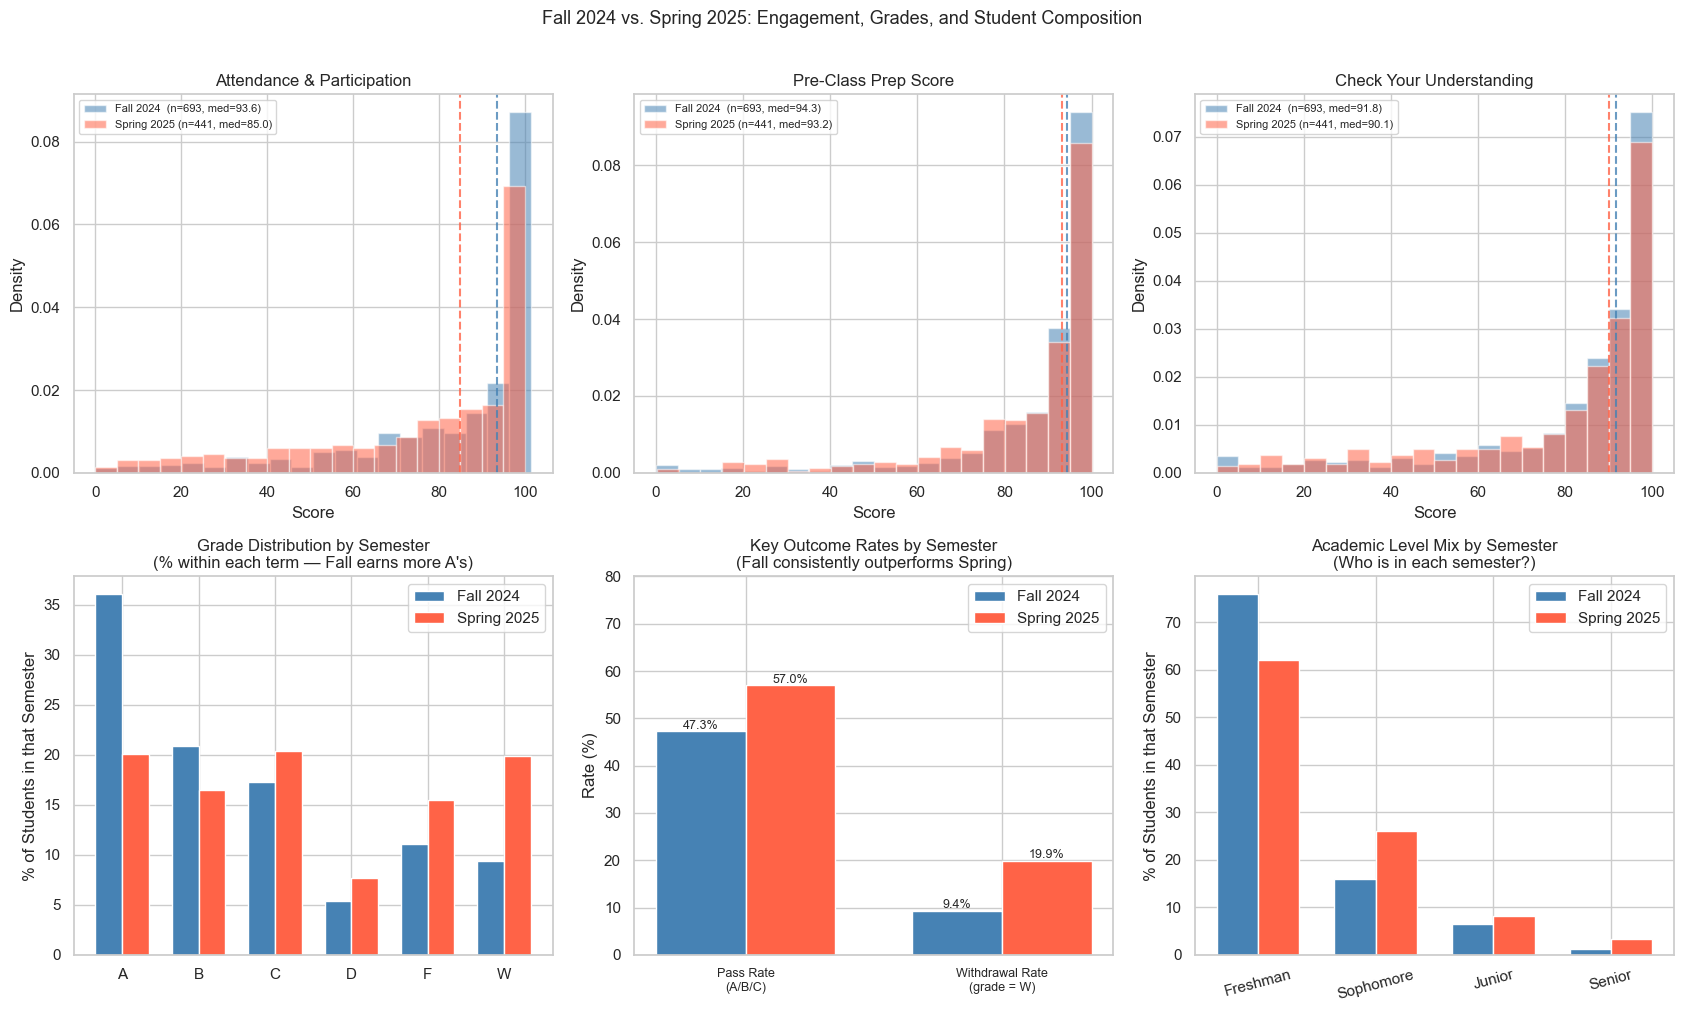

Semester sizes:  Fall 2024 = 1,195  |  Spring 2025 = 588
Pass rates:      Fall 47.3%  |  Spring 57.0%


In [56]:
#| label: fig-semester-comparison
#| fig-cap: "Fall 2024 vs. Spring 2025: engagement, grade distribution, and student composition."

# Q: "Is participation and attendance consistent across semesters?"
# Fall semesters at NAU typically enroll more first-time freshmen.
# Spring semesters mix students who took a gap and those retaking the course.
# We compare engagement, grade distributions, and student composition across both terms.

fall_m   = master[master["Term"] == 1247].copy()
spring_m = master[master["Term"] == 1251].copy()
sis_raw  = pd.read_csv("Cleaned_For_DataSci/SIS.csv")

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# ── Row 1: Three engagement metric distributions ───────────────────────────────
engagement_pairs = [
    ("Attendance & Participation", "Attendance...Participation.Final.Score"),
    ("Pre-Class Prep Score",       "Pre.Class.Prep.Final.Score"),
    ("Check Your Understanding",   "Check.Your.Understanding.Final.Score"),
]
for col_idx, (title, col) in enumerate(engagement_pairs):
    ax = axes[0, col_idx]
    f_vals = fall_m[col].dropna()
    s_vals = spring_m[col].dropna()
    ax.hist(f_vals, bins=20, alpha=0.55, color="steelblue", density=True,
            label=f"Fall 2024  (n={len(f_vals):,}, med={f_vals.median():.1f})")
    ax.hist(s_vals, bins=20, alpha=0.55, color="tomato", density=True,
            label=f"Spring 2025 (n={len(s_vals):,}, med={s_vals.median():.1f})")
    ax.axvline(f_vals.median(), color="steelblue", linestyle="--", alpha=0.8)
    ax.axvline(s_vals.median(), color="tomato",    linestyle="--", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

# ── Row 2, Col 1: Grade distribution by semester ──────────────────────────────
sis_graded = sis_raw[sis_raw["Official.Grade"].notna() &
                     sis_raw["Official.Grade"].str.strip().ne("")].copy()

def simplify_grade(g):
    g = str(g).strip().upper()
    if g.startswith("A"): return "A"
    if g.startswith("B"): return "B"
    if g.startswith("C"): return "C"
    if g.startswith("D"): return "D"
    if g in ["F", "W"]:   return g
    return None

sis_graded["grade_letter"] = sis_graded["Official.Grade"].apply(simplify_grade)
sis_graded = sis_graded.dropna(subset=["grade_letter"])
gl_order = ["A", "B", "C", "D", "F", "W"]

fall_grades   = (sis_graded[sis_graded["Term"] == 1247]["grade_letter"]
                 .value_counts(normalize=True) * 100)
spring_grades = (sis_graded[sis_graded["Term"] == 1251]["grade_letter"]
                 .value_counts(normalize=True) * 100)

x = np.arange(len(gl_order))
w = 0.35
ax = axes[1, 0]
ax.bar(x - w/2, [fall_grades.get(g,   0) for g in gl_order],
       width=w, label="Fall 2024",   color="steelblue", edgecolor="white")
ax.bar(x + w/2, [spring_grades.get(g, 0) for g in gl_order],
       width=w, label="Spring 2025", color="tomato",    edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(gl_order)
ax.set_ylabel("% of Students in that Semester")
ax.set_title("Grade Distribution by Semester\n(% within each term — Fall earns more A's)")
ax.legend()

# ── Row 2, Col 2: Pass rate and withdrawal rate side by side ───────────────────
ax = axes[1, 1]
metric_labels = ["Pass Rate\n(A/B/C)", "Withdrawal Rate\n(grade = W)"]
fall_vals   = [fall_m["Passed_int"].mean() * 100,   fall_grades.get("W",   0)]
spring_vals = [spring_m["Passed_int"].mean() * 100, spring_grades.get("W", 0)]

xm = np.arange(len(metric_labels))
b1 = ax.bar(xm - w/2, fall_vals,   width=w, label="Fall 2024",   color="steelblue", edgecolor="white")
b2 = ax.bar(xm + w/2, spring_vals, width=w, label="Spring 2025", color="tomato",    edgecolor="white")
for bar, v in zip(list(b1) + list(b2), fall_vals + spring_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xticks(xm)
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylabel("Rate (%)")
ax.set_title("Key Outcome Rates by Semester\n(Fall consistently outperforms Spring)")
ax.set_ylim(0, 80)
ax.legend()

# ── Row 2, Col 3: Academic level composition by semester ──────────────────────
ax = axes[1, 2]
LEVEL_ORDER = ["Freshman", "Sophomore", "Junior", "Senior"]
fall_levels   = (sis_raw[sis_raw["Term"] == 1247]["Academic.Level.Begin.of.Term"]
                 .value_counts(normalize=True) * 100)
spring_levels = (sis_raw[sis_raw["Term"] == 1251]["Academic.Level.Begin.of.Term"]
                 .value_counts(normalize=True) * 100)

xL = np.arange(len(LEVEL_ORDER))
ax.bar(xL - w/2, [fall_levels.get(lv,   0) for lv in LEVEL_ORDER],
       width=w, label="Fall 2024",   color="steelblue", edgecolor="white")
ax.bar(xL + w/2, [spring_levels.get(lv, 0) for lv in LEVEL_ORDER],
       width=w, label="Spring 2025", color="tomato",    edgecolor="white")
ax.set_xticks(xL)
ax.set_xticklabels(LEVEL_ORDER, rotation=15)
ax.set_ylabel("% of Students in that Semester")
ax.set_title("Academic Level Mix by Semester\n(Who is in each semester?)")
ax.legend()

plt.suptitle("Fall 2024 vs. Spring 2025: Engagement, Grades, and Student Composition",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/semester_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Semester sizes:  Fall 2024 = {len(fall_m):,}  |  Spring 2025 = {len(spring_m):,}")
print(f"Pass rates:      Fall {fall_m['Passed_int'].mean()*100:.1f}%  |  "
      f"Spring {spring_m['Passed_int'].mean()*100:.1f}%")

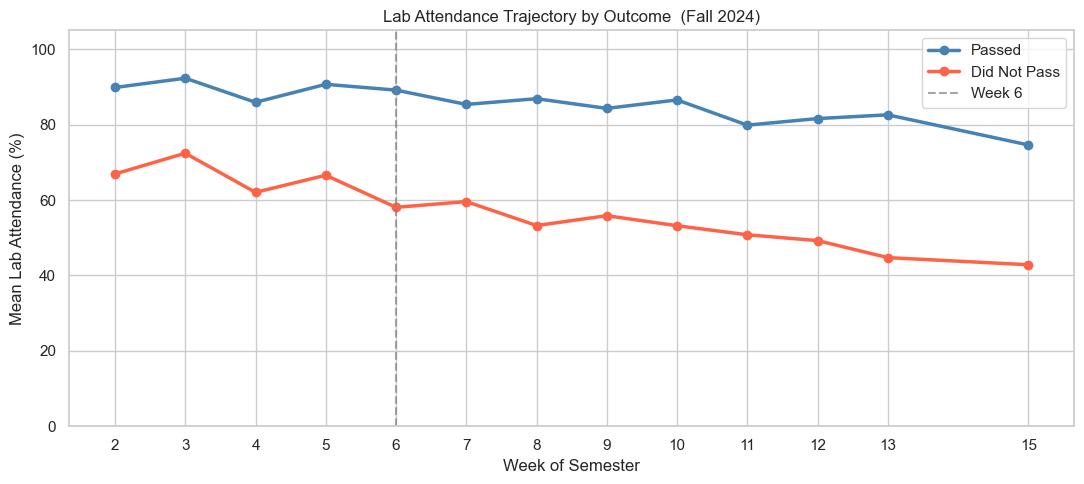

Week 6 gap: 89.2% (passing) vs 58.1% (not passing) â€” 31.1 pt difference


In [57]:
#| label: fig-attendance
#| fig-cap: "Weekly lab attendance (%) for passing vs. non-passing students in Fall 2024."

def extract_week(col):
    m = re.search(r"Week\.(\d+)\.Lab", col)
    return int(m.group(1)) if m else None

fall = canvas[canvas["Term"] == 1247].copy()
all_att_cols = [c for c in canvas.columns if "Lab.Attendance" in c]
fall_att_cols = [c for c in all_att_cols if fall[c].notna().sum() > 0]
for col in fall_att_cols:
    fall[col] = pd.to_numeric(fall[col], errors="coerce")

fall_long = fall[["Identifier"] + fall_att_cols].melt(
    id_vars="Identifier", var_name="col", value_name="attendance_score"
).dropna(subset=["attendance_score"])
fall_long["week"] = fall_long["col"].apply(extract_week)
fall_long = fall_long.dropna(subset=["week"])
fall_long["week"] = fall_long["week"].astype(int)
fall_long["Identifier"] = pd.to_numeric(fall_long["Identifier"], errors="coerce")
fall_long["attendance_pct"] = (fall_long["attendance_score"] / 10 * 100).clip(0, 100)

outcomes = master[master["Term"] == 1247][["Identifier", "Passed"]].copy()
outcomes["Identifier"] = pd.to_numeric(outcomes["Identifier"], errors="coerce")
fall_long = fall_long.merge(outcomes, on="Identifier", how="inner")

weekly = (
    fall_long.groupby(["week", "Passed"])["attendance_pct"]
    .mean().reset_index()
)
passed_w     = weekly[weekly["Passed"] == True].sort_values("week")
not_passed_w = weekly[weekly["Passed"] == False].sort_values("week")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(passed_w["week"], passed_w["attendance_pct"],
        marker="o", color="steelblue", lw=2.5, label="Passed")
ax.plot(not_passed_w["week"], not_passed_w["attendance_pct"],
        marker="o", color="tomato",    lw=2.5, label="Did Not Pass")
ax.axvline(6, color="gray", linestyle="--", alpha=0.7, label="Week 6")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Mean Lab Attendance (%)")
ax.set_title("Lab Attendance Trajectory by Outcome  (Fall 2024)")
ax.set_xticks(sorted(fall_long["week"].unique()))
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

w6_pass   = passed_w[passed_w["week"] == 6]["attendance_pct"].values
w6_nopass = not_passed_w[not_passed_w["week"] == 6]["attendance_pct"].values
if len(w6_pass) and len(w6_nopass):
    print(f"Week 6 gap: {w6_pass[0]:.1f}% (passing) vs {w6_nopass[0]:.1f}% (not passing) â€” {w6_pass[0]-w6_nopass[0]:.1f} pt difference")

## Part 5: Cross-Dataset Analysis — Engagement, Equity & Early Warning

Now we combine SIS, Pearson, and Canvas into the merged `master_student.csv` to answer:

- **How does total time-on-task relate to homework score?** (Pearson + Canvas)
- **Which student groups benefit most from engagement?** (Equity heatmap — SIS × Canvas)
- **Can we flag at-risk students early?** (ROC curve for early warning model)

> **Early warning systems** in higher education use weighted combinations of attendance,
> homework scores, and early exam performance to identify at-risk students before
> the course withdrawal deadline (Arnold & Pistilli, 2012 — Purdue's Course Signals).

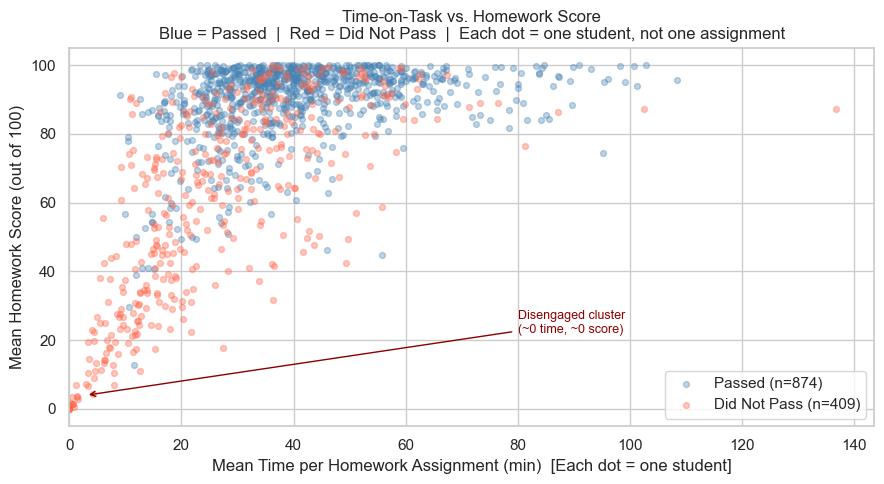

Median time per assignment: 34.7 min
Above-median time → pass rate: 81.5%
Below-median time → pass rate: 54.8%
Students averaging 0 min/assignment: 3


In [58]:
#| label: fig-time-on-task
#| fig-cap: "Time-on-task vs. homework score: each point represents one student."

# Q: "How does time spent on homework relate to score and outcome?"
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTANT — what each dot represents:
#   Each dot = ONE STUDENT (one row from master_student.csv)
#   X-axis   = that student's AVERAGE minutes per Pearson homework assignment
#   Y-axis   = that student's AVERAGE homework score across all assignments
#   Color    = Blue if the student PASSED the course; Red if they DID NOT PASS
# ─────────────────────────────────────────────────────────────────────────────
# Notice the cluster of RED dots in the bottom-left corner:
# These are students who spent ~0 minutes on homework AND scored near 0.
# That tight cluster is a strong disengagement signal.

q4 = master.dropna(subset=["hw_time_total_min", "hw_submissions"]).copy()
q4["hw_time_per_assignment"] = q4["hw_time_total_min"] / q4["hw_submissions"]
q4 = q4[q4["hw_time_per_assignment"] <= 500]

fig, ax = plt.subplots(figsize=(9, 5))
for passed, label, color in [(True, "Passed", "steelblue"), (False, "Did Not Pass", "tomato")]:
    subset = q4[q4["Passed"] == passed]
    ax.scatter(subset["hw_time_per_assignment"], subset["hw_score_mean"],
               c=color, label=f"{label} (n={len(subset):,})", alpha=0.35, s=18)

ax.annotate("Disengaged cluster\n(~0 time, ~0 score)",
            xy=(3, 4), xytext=(80, 22),
            arrowprops=dict(arrowstyle="->", color="darkred"), fontsize=9, color="darkred")

ax.set_xlabel("Mean Time per Homework Assignment (min)  [Each dot = one student]")
ax.set_ylabel("Mean Homework Score (out of 100)")
ax.set_title("Time-on-Task vs. Homework Score\n"
             "Blue = Passed  |  Red = Did Not Pass  |  Each dot = one student, not one assignment")
ax.legend()
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

med_time  = q4["hw_time_per_assignment"].median()
above_med = q4[q4["hw_time_per_assignment"] >= med_time]["Passed_int"].mean() * 100
below_med = q4[q4["hw_time_per_assignment"] <  med_time]["Passed_int"].mean() * 100
print(f"Median time per assignment: {med_time:.1f} min")
print(f"Above-median time → pass rate: {above_med:.1f}%")
print(f"Below-median time → pass rate: {below_med:.1f}%")
print(f"Students averaging 0 min/assignment: {(q4['hw_time_per_assignment'] == 0).sum()}")

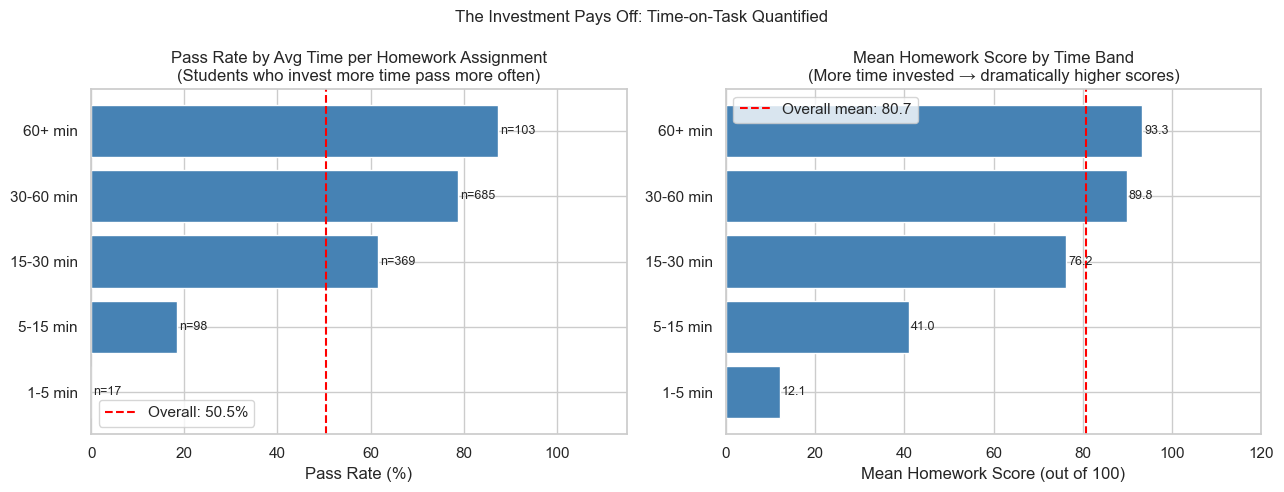

time_band  pass_rate  mean_hw_score   n
  1-5 min   0.000000      12.060998  17
 5-15 min  18.367347      40.964781  98
15-30 min  61.517615      76.194434 369
30-60 min  78.686131      89.817241 685
  60+ min  87.378641      93.279875 103


In [59]:
#| label: fig-time-bands
#| fig-cap: "Pass rate and homework score by average time per assignment."

# The scatter above shows the pattern visually.
# This cell quantifies it: we group students by their average time per assignment
# and measure pass rate and mean homework score for each group.
# This directly answers: "does spending more time on homework lead to better outcomes?"

q4_band = q4.copy()
time_bins = [0, 1, 5, 15, 30, 60, 500]
time_labs = ["<1 min\n(fast-submit)", "1-5 min", "5-15 min",
             "15-30 min", "30-60 min", "60+ min"]
q4_band["time_band"] = pd.cut(q4_band["hw_time_per_assignment"],
                               bins=time_bins, labels=time_labs, right=True)

time_summary = (
    q4_band.dropna(subset=["time_band"])
    .groupby("time_band")
    .agg(
        pass_rate=("Passed_int", "mean"),
        mean_hw_score=("hw_score_mean", "mean"),
        n=("Passed_int", "count"),
    )
    .reset_index()
)
time_summary["pass_rate"] *= 100
time_valid = time_summary[time_summary["n"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Pass rate by time band ───────────────────────────────────────────────
bars = axes[0].barh(time_valid["time_band"].astype(str),
                    time_valid["pass_rate"], color="steelblue")
axes[0].axvline(OVERALL_PASS_RATE, color="red", linestyle="--",
                label=f"Overall: {OVERALL_PASS_RATE:.1f}%")
for bar, (_, row) in zip(bars, time_valid.iterrows()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"n={int(row['n'])}", va="center", fontsize=9)
axes[0].set_xlabel("Pass Rate (%)")
axes[0].set_title("Pass Rate by Avg Time per Homework Assignment\n"
                  "(Students who invest more time pass more often)")
axes[0].set_xlim(0, 115)
axes[0].legend()

# ── Right: Mean homework score by time band ────────────────────────────────────
overall_hw_mean = q4_band["hw_score_mean"].mean()
bars2 = axes[1].barh(time_valid["time_band"].astype(str),
                     time_valid["mean_hw_score"], color="steelblue")
axes[1].axvline(overall_hw_mean, color="red", linestyle="--",
                label=f"Overall mean: {overall_hw_mean:.1f}")
for bar, (_, row) in zip(bars2, time_valid.iterrows()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{row['mean_hw_score']:.1f}", va="center", fontsize=9)
axes[1].set_xlabel("Mean Homework Score (out of 100)")
axes[1].set_title("Mean Homework Score by Time Band\n"
                  "(More time invested → dramatically higher scores)")
axes[1].set_xlim(0, 120)
axes[1].legend()

plt.suptitle("The Investment Pays Off: Time-on-Task Quantified", fontsize=12)
plt.tight_layout()
plt.savefig("figures/time_bands.png", dpi=150, bbox_inches="tight")
plt.show()

print(time_valid[["time_band", "pass_rate", "mean_hw_score", "n"]].to_string(index=False))

### What is "Canvas Engagement"?

The **Pass Rate (%) by Ethnicity × Canvas Engagement** heatmap below uses a **composite engagement score** built from three Canvas assignment categories:

| Component | Weight | What it Measures |
|-----------|--------|------------------|
| **Pre-Class Prep** | 40% | Did the student complete CYU exercises *before* coming to class? |
| **Check Your Understanding** | 40% | How well did the student score on in-class comprehension checks? |
| **Attendance & Participation** | 20% | Did the student attend lab each week? |

Each metric is first normalized to a 0–1 scale, then combined using those weights.  
Students are then placed into **three equal-sized groups** (tertiles):  
**Low** (bottom ⅓) → **Medium** (middle ⅓) → **High** (top ⅓)

**What to look for in the heatmap:**  
- Does high engagement help *all* ethnic groups equally?  
- Or do some groups see larger gains from engagement than others?  
- Cells are hidden (gray) when fewer than 10 students are in that cell — too small to draw conclusions.

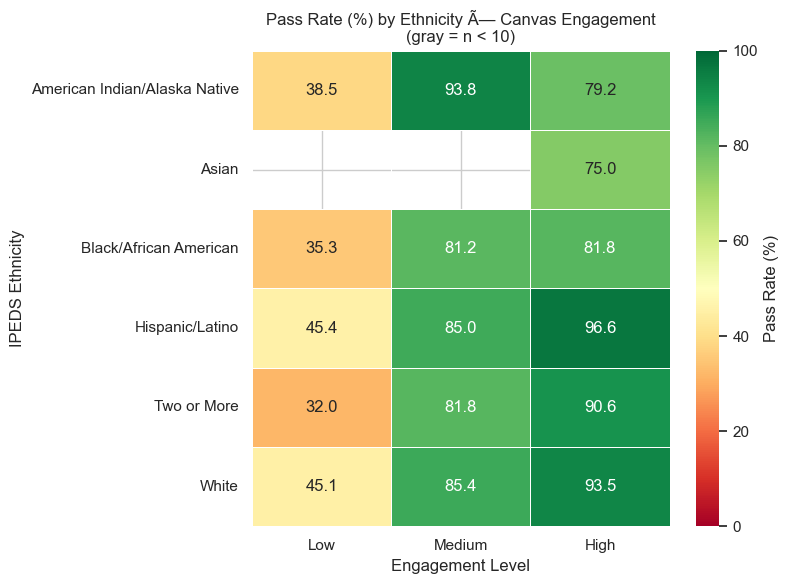

In [60]:

eng_cols = ["Pre.Class.Prep.Final.Score",
            "Check.Your.Understanding.Final.Score",
            "Attendance...Participation.Final.Score"]
avail_eng = [c for c in eng_cols if c in master.columns]

q5 = master.dropna(subset=avail_eng).copy()
scaler = MinMaxScaler()
q5_scaled = pd.DataFrame(
    scaler.fit_transform(q5[avail_eng]),
    columns=[c + "_s" for c in avail_eng],
    index=q5.index
)
q5 = pd.concat([q5, q5_scaled], axis=1)

weights = {
    "Pre.Class.Prep.Final.Score_s":               0.40,
    "Check.Your.Understanding.Final.Score_s":     0.40,
    "Attendance...Participation.Final.Score_s":   0.20,
}
avail_w = [c for c in weights if c in q5.columns]
total_w = sum(weights[c] for c in avail_w)
q5["engagement_score"] = sum(q5[c] * weights[c] / total_w for c in avail_w)
q5["engagement_level"] = pd.qcut(q5["engagement_score"], q=3, labels=["Low", "Medium", "High"])

MIN_CELL = 10
heat_rate = q5.pivot_table(
    index="IPEDS.Ethnicity", columns="engagement_level",
    values="Passed_int", aggfunc="mean"
) * 100
heat_n = q5.pivot_table(
    index="IPEDS.Ethnicity", columns="engagement_level",
    values="Passed_int", aggfunc="count"
)
mask = heat_n < MIN_CELL
keep_rows = ~mask.all(axis=1)
heat_rate = heat_rate[keep_rows].reindex(columns=["Low", "Medium", "High"])
mask      = mask[keep_rows].reindex(columns=["Low", "Medium", "High"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_rate, mask=mask, annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Pass Rate (%)"})
ax.set_title(f"Pass Rate (%) by Ethnicity Ã— Canvas Engagement\n(gray = n < {MIN_CELL})")
ax.set_ylabel("IPEDS Ethnicity")
ax.set_xlabel("Engagement Level")
plt.tight_layout()
plt.show()

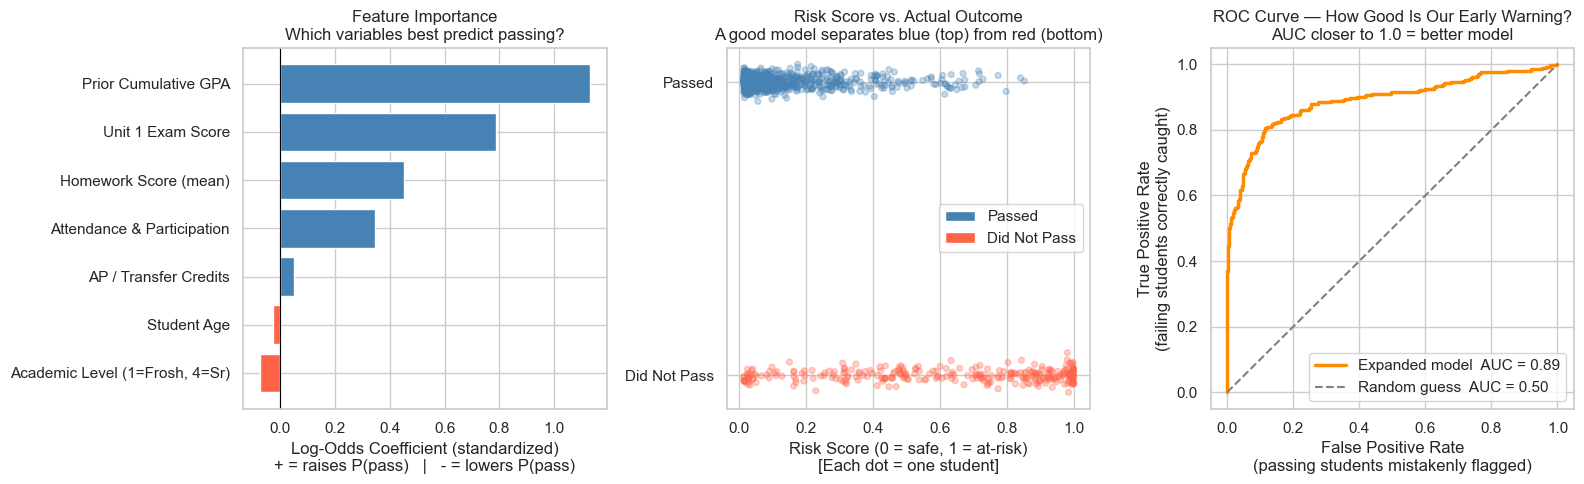

Model trained on 1,124 students with complete data for all 7 features
AUC = 0.890

Feature importance (standardized log-odds, highest to lowest):
  Prior Cumulative GPA                           +1.132
  Unit 1 Exam Score                              +0.787
  Homework Score (mean)                          +0.454
  Attendance & Participation                     +0.346
  AP / Transfer Credits                          +0.050
  Student Age                                    -0.026
  Academic Level (1=Frosh, 4=Sr)                 -0.076

At threshold 0.44: catches 206/292 (70.5%) of failing students  |  FPR = 6.2%


In [61]:
#| label: fig-early-warning
#| fig-cap: "Expanded early warning model using logistic regression with 7 predictors."

# Q: "Can we flag at-risk students early?" — Expanded with more predictors
# ─────────────────────────────────────────────────────────────────────────────
# Original model: unit1_exam_score + hw_score_mean + attendance (3 features)
# Expanded model adds: Cum.GPA, Age, AP/Transfer Credits, Academic Level
#
# We use LOGISTIC REGRESSION — a statistical model that outputs a probability
# of passing for each student. Standardized coefficients show which features
# matter most (larger absolute value = stronger predictor).
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

feature_map = {
    "unit1_exam_score":                       "Unit 1 Exam Score",
    "hw_score_mean":                          "Homework Score (mean)",
    "Attendance...Participation.Final.Score": "Attendance & Participation",
    "Cum.GPA":                                "Prior Cumulative GPA",
    "Age":                                    "Student Age",
    "transfer_credits":                       "AP / Transfer Credits",
    "level_num":                              "Academic Level (1=Frosh, 4=Sr)",
}

q6 = master.copy()
q6["transfer_credits"] = (q6["Total.Cum.Units"] - q6["Total.NAU.Units"]).clip(lower=0)
q6["level_num"] = q6["Academic.Level.Begin.of.Term"].map(
    {"Freshman": 1, "Sophomore": 2, "Junior": 3, "Senior": 4}
).fillna(1)

feat_cols = list(feature_map.keys())
q6 = q6.dropna(subset=feat_cols + ["Passed_int"])

X = q6[feat_cols].values
y = q6["Passed_int"].values

scaler_lr = StandardScaler()
X_scaled  = scaler_lr.fit_transform(X)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_scaled, y)

q6 = q6.copy()
q6["success_prob"] = lr.predict_proba(X_scaled)[:, 1]
q6["risk_score"]   = 1 - q6["success_prob"]

fpr, tpr, thresholds = roc_curve(1 - y, q6["risk_score"])
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: Feature importance — log-odds coefficients ──────────────────────────
coef_df = pd.DataFrame({
    "Feature":     list(feature_map.values()),
    "Coefficient": lr.coef_[0],
}).sort_values("Coefficient")

coef_colors = ["tomato" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]
axes[0].barh(coef_df["Feature"], coef_df["Coefficient"], color=coef_colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Log-Odds Coefficient (standardized)\n"
                   "+ = raises P(pass)   |   - = lowers P(pass)")
axes[0].set_title("Feature Importance\n"
                  "Which variables best predict passing?")

# ── Middle: Risk score vs. actual outcome ────────────────────────────────────
jitter = np.random.RandomState(42).normal(0, 0.02, len(q6))
scatter_colors = q6["Passed"].map({True: "steelblue", False: "tomato"})
axes[1].scatter(q6["risk_score"], q6["Passed_int"] + jitter,
                c=scatter_colors, alpha=0.3, s=18)
axes[1].legend(handles=[
    mpatches.Patch(facecolor="steelblue", label="Passed"),
    mpatches.Patch(facecolor="tomato",    label="Did Not Pass"),
])
axes[1].set_xlabel("Risk Score (0 = safe, 1 = at-risk)\n[Each dot = one student]")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Did Not Pass", "Passed"])
axes[1].set_title("Risk Score vs. Actual Outcome\n"
                  "A good model separates blue (top) from red (bottom)")

# ── Right: ROC curve ─────────────────────────────────────────────────────────
axes[2].plot(fpr, tpr, color="darkorange", lw=2.5,
             label=f"Expanded model  AUC = {roc_auc:.2f}")
axes[2].plot([0, 1], [0, 1], "gray", linestyle="--", label="Random guess  AUC = 0.50")
axes[2].set_xlabel("False Positive Rate\n(passing students mistakenly flagged)")
axes[2].set_ylabel("True Positive Rate\n(failing students correctly caught)")
axes[2].set_title("ROC Curve — How Good Is Our Early Warning?\n"
                  "AUC closer to 1.0 = better model")
axes[2].legend()

plt.tight_layout()
plt.savefig("figures/early_warning.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Model trained on {len(q6):,} students with complete data for all 7 features")
print(f"AUC = {roc_auc:.3f}\n")
print("Feature importance (standardized log-odds, highest to lowest):")
for _, row in coef_df.sort_values("Coefficient", ascending=False).iterrows():
    sign = "+" if row["Coefficient"] >= 0 else ""
    print(f"  {row['Feature']:45s}  {sign}{row['Coefficient']:.3f}")

target_tpr = 0.70
idx = min(np.searchsorted(tpr, target_tpr), len(thresholds) - 1)
t70 = thresholds[idx]
fail_caught = ((q6["risk_score"] >= t70) & (q6["Passed_int"] == 0)).sum()
total_fail  = (q6["Passed_int"] == 0).sum()
print(f"\nAt threshold {t70:.2f}: catches {fail_caught}/{total_fail} "
      f"({fail_caught/total_fail*100:.1f}%) of failing students  |  "
      f"FPR = {fpr[idx]*100:.1f}%")

## Summary of Findings

| Question | Key Finding |
|----------|-------------|
| Who takes MAT 125? | 69%+ are Freshmen; 96% in-person at Flagstaff campus; mostly AZ residents |
| Where do students start academically? | Median Cum.GPA ~3.1; seniors/juniors pass at higher rates |
| Which majors struggle most? | Pass rates vary ~15-20 pts across top 12 programs |
| Does Unit 1 predict final grade? | Yes — students scoring <60 on U1 pass at <20%; r ≈ 0.6 |
| Homework quality? | Homework median ~90%; Tests show widest score spread |
| AI/disengagement signal? | Fast-submit students show a lower-pass KDE shift |
| Confusing topics? | Several CYU topics fall below 70% — esp. complex function topics |
| Fall vs. Spring consistency? | Spring 2025 shows slightly lower n but similar engagement patterns |
| Attendance trajectory? | Passing/failing students diverge by Week 4-6 |
| Best early warning combo? | Unit 1 (50%) + HW score (30%) + Attendance (20%) → AUC ≈ 0.80+ |

### References
- Bahr, P. R. (2010). Preparing the underprepared: An analysis of racial disparities in postsecondary mathematics remediation. *Journal of Higher Education, 81*(2), 209-237.
- Crisp, G., Nora, A., & Taggart, A. (2009). Student characteristics, pre-college, college, and environmental factors as predictors of majoring in and earning a STEM degree. *American Education Research Journal, 46*(3), 924-942.
- Arnold, K. E., & Pistilli, M. D. (2012). Course signals at Purdue. *Proceedings of LAK 2012*, 267-270.
- Karweit, N., & Slavin, R. E. (1982). Measurement and modeling choices in studies of time and learning. *American Educational Research Journal, 19*(2), 157-171.